In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, balanced_accuracy_score, classification_report
from sklearn.datasets import load_breast_cancer

import warnings
warnings.filterwarnings("ignore")

In [2]:
feature_space = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity']

In [3]:
data = load_breast_cancer()

df_og = pd.DataFrame(data.data, columns=data.feature_names)
df_og['target'] = data.target

df_og.sample(1)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
342,11.06,14.96,71.49,373.9,0.1033,0.09097,0.05397,0.03341,0.1776,0.06907,...,19.9,79.76,440.0,0.1418,0.221,0.2299,0.1075,0.3301,0.0908,1


In [4]:
df_og.value_counts('target')

target
1    357
0    212
Name: count, dtype: int64

In [5]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df_og, test_size=0.3, random_state=0, stratify=df_og['target'])

X_test = test[feature_space]
y_test = test['target']

In [6]:
df_majority = train[train['target'] == 1]
df_minority = train[train['target'] == 0]

df_minority_undersampled = df_minority.sample(n=5, random_state=1)

df = pd.concat([df_majority, df_minority_undersampled])
df = df.sample(frac=1, random_state=1).reset_index(drop=True)

print('train df contains {} samples with target 0 and {} samples with target 1'.format(df['target'].value_counts()[0], df['target'].value_counts()[1]))

train df contains 5 samples with target 0 and 250 samples with target 1


In [7]:
import xgboost as xgb

X_train = df[feature_space]
y_train = df['target']

model = xgb.XGBClassifier(random_state=0)
model.fit(X_train, y_train)

y_preds = model.predict(X_test)

balanced_acc = balanced_accuracy_score(y_test, y_preds)
print("Balanced accuracy:", balanced_acc)

print(classification_report(y_test, y_preds, target_names=['Class 0','Class 1']))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_preds))


Balanced accuracy: 0.6703417056074766
              precision    recall  f1-score   support

     Class 0       0.92      0.36      0.52        64
     Class 1       0.72      0.98      0.83       107

    accuracy                           0.75       171
   macro avg       0.82      0.67      0.67       171
weighted avg       0.79      0.75      0.71       171

Balanced accuracy: 0.6703417056074766


In [8]:
df_base = df_minority_undersampled

In [9]:
from sdv.single_table import GaussianCopulaSynthesizer, CTGANSynthesizer
from sdv.metadata import Metadata
from imblearn.over_sampling import SMOTE, ADASYN, SVMSMOTE, KMeansSMOTE, RandomOverSampler

In [10]:
def generate_minority_df(df_majority, df_minority, ratio: int, synthesizer: str):
    n_majority = len(df_majority)
    desired_minority_total = n_majority // ratio
    n_to_generate = max(desired_minority_total - len(df_minority), 0)
    df_synth = pd.DataFrame()
    
    if n_to_generate == 0:
        return pd.concat([df_majority, df_minority]).reset_index(drop=True)
    
    if synthesizer == 'gaussian':
    
        metadata = Metadata.detect_from_dataframe(data=df_minority)
        gc = GaussianCopulaSynthesizer(metadata)
        gc.fit(df_minority)
        df_synth = gc.sample(n_to_generate)

    elif synthesizer == 'ctgan':

        metadata = Metadata.detect_from_dataframe(data=df_minority)
        ctgan = CTGANSynthesizer(metadata, cuda=False)
        ctgan.fit(df_minority)
        df_synth = ctgan.sample(n_to_generate)

    elif synthesizer == 'smote':

        smote = SMOTE(sampling_strategy=1/ratio, random_state=0, k_neighbors=4)
        tmp = pd.concat([df_majority, df_minority]).reset_index(drop=True)
        X_tmp = tmp[feature_space]
        y_tmp = tmp['target']
        X_train_sm, y_train_sm = smote.fit_resample(X_tmp, y_tmp)
        tmp = pd.concat([X_train_sm, y_train_sm], axis=1).reset_index(drop=True)
        
        return tmp[feature_space], tmp['target']
    
    elif synthesizer == 'adasyn':

        adasyn = ADASYN(sampling_strategy=1/ratio, random_state=0, n_neighbors=4)
        tmp = pd.concat([df_majority, df_minority]).reset_index(drop=True)
        X_tmp = tmp[feature_space]
        y_tmp = tmp['target']
        X_train_sm, y_train_sm = adasyn.fit_resample(X_tmp, y_tmp)
        tmp = pd.concat([X_train_sm, y_train_sm], axis=1).reset_index(drop=True)
        
        return tmp[feature_space], tmp['target']
    
    elif synthesizer == 'svm_smote':

        svm_smote = SVMSMOTE(sampling_strategy=1/ratio, random_state=0, k_neighbors=4)
        tmp = pd.concat([df_majority, df_minority]).reset_index(drop=True)
        X_tmp = tmp[feature_space]
        y_tmp = tmp['target']
        X_train_sm, y_train_sm = svm_smote.fit_resample(X_tmp, y_tmp)
        tmp = pd.concat([X_train_sm, y_train_sm], axis=1).reset_index(drop=True)
        
        return tmp[feature_space], tmp['target']
    
    elif synthesizer == 'kmeans_smote':

        kmeans_smote = KMeansSMOTE(sampling_strategy=1/ratio, random_state=0, k_neighbors=4)
        tmp = pd.concat([df_majority, df_minority]).reset_index(drop=True)
        X_tmp = tmp[feature_space]
        y_tmp = tmp['target']
        X_train_sm, y_train_sm = kmeans_smote.fit_resample(X_tmp, y_tmp)
        tmp = pd.concat([X_train_sm, y_train_sm], axis=1).reset_index(drop=True)
        
        return tmp[feature_space], tmp['target']
    
    elif synthesizer == 'random_oversample':

        tmp = pd.concat([df_majority, df_minority]).reset_index(drop=True)
        X_tmp = tmp[feature_space]
        y_tmp = tmp['target']

        ros = RandomOverSampler(
            sampling_strategy={0: desired_minority_total},
            random_state=0
        )

        X_res, y_res = ros.fit_resample(X_tmp, y_tmp)
        tmp_res = pd.concat([X_res, y_res], axis=1).reset_index(drop=True)

        return tmp_res[feature_space], tmp_res['target']

    df_minority_expanded = pd.concat([df_minority, df_synth]).reset_index(drop=True)
    df_combined = pd.concat([df_majority, df_minority_expanded]).reset_index(drop=True)
    
    return df_combined[feature_space], df_combined['target']

In [11]:
X_dfGaussian25, y_dfGaussian25 = generate_minority_df(df_majority, df_minority_undersampled, ratio=25, synthesizer='gaussian')
X_dfGaussian10, y_dfGaussian10 = generate_minority_df(df_majority, df_minority_undersampled, ratio=10, synthesizer='gaussian')
X_dfGaussian5, y_dfGaussian5 = generate_minority_df(df_majority, df_minority_undersampled, ratio=5, synthesizer='gaussian')  
X_dfGaussian2, y_dfGaussian2 = generate_minority_df(df_majority, df_minority_undersampled, ratio=2, synthesizer='gaussian')
X_dfGaussian1, y_dfGaussian1 = generate_minority_df(df_majority, df_minority_undersampled, ratio=1, synthesizer='gaussian')

In [12]:
len(X_dfGaussian25)

260

In [13]:
X_dfCTGAN25, y_dfCTGAN25 = generate_minority_df(df_majority, df_minority_undersampled, ratio=25, synthesizer='ctgan')
X_dfCTGAN10, y_dfCTGAN10 = generate_minority_df(df_majority, df_minority_undersampled, ratio=10, synthesizer='ctgan')
X_dfCTGAN5, y_dfCTGAN5 = generate_minority_df(df_majority, df_minority_undersampled, ratio=5, synthesizer='ctgan')
X_dfCTGAN2, y_dfCTGAN2 = generate_minority_df(df_majority, df_minority_undersampled, ratio=2, synthesizer='ctgan')
X_dfCTGAN1, y_dfCTGAN1 = generate_minority_df(df_majority, df_minority_undersampled, ratio=1, synthesizer='ctgan')

In [14]:
X_dfSMOTE25, y_dfSMOTE25 = generate_minority_df(df_majority, df_minority_undersampled, ratio=25, synthesizer='smote')
X_dfSMOTE10, y_dfSMOTE10 = generate_minority_df(df_majority, df_minority_undersampled, ratio=10, synthesizer='smote')
X_dfSMOTE5, y_dfSMOTE5 = generate_minority_df(df_majority, df_minority_undersampled, ratio=5, synthesizer='smote')  
X_dfSMOTE2, y_dfSMOTE2 = generate_minority_df(df_majority, df_minority_undersampled, ratio=2, synthesizer='smote')  
X_dfSMOTE1, y_dfSMOTE1 = generate_minority_df(df_majority, df_minority_undersampled, ratio=1, synthesizer='smote')     

In [15]:
X_dfADASYN25, y_dfADASYN25 = generate_minority_df(df_majority, df_minority_undersampled, ratio=25, synthesizer='adasyn')
X_dfADASYN10, y_dfADASYN10 = generate_minority_df(df_majority, df_minority_undersampled, ratio=10, synthesizer='adasyn')
X_dfADASYN5, y_dfADASYN5 = generate_minority_df(df_majority, df_minority_undersampled, ratio=5, synthesizer='adasyn')
X_dfADASYN2, y_dfADASYN2 = generate_minority_df(df_majority, df_minority_undersampled, ratio=2, synthesizer='adasyn')
X_dfADASYN1, y_dfADASYN1 = generate_minority_df(df_majority, df_minority_undersampled, ratio=1, synthesizer='adasyn')

In [16]:
X_dfRandom25, y_dfRandom25 = generate_minority_df(df_majority, df_minority_undersampled, ratio=25, synthesizer='random_oversample')
X_dfRandom10, y_dfRandom10 = generate_minority_df(df_majority, df_minority_undersampled, ratio=10, synthesizer='random_oversample')
X_dfRandom5, y_dfRandom5 = generate_minority_df(df_majority, df_minority_undersampled, ratio=5, synthesizer='random_oversample')
X_dfRandom2, y_dfRandom2 = generate_minority_df(df_majority, df_minority_undersampled, ratio=2, synthesizer='random_oversample')
X_dfRandom1, y_dfRandom1 = generate_minority_df(df_majority, df_minority_undersampled, ratio=1, synthesizer='random_oversample')

In [17]:
print(y_dfGaussian2.value_counts('target'), y_dfCTGAN2.value_counts('target'), y_dfSMOTE2.value_counts('target')
, y_dfADASYN2.value_counts('target'), y_dfRandom2.value_counts('target'))
print(len(y_dfGaussian2), len(y_dfCTGAN2), len(y_dfSMOTE2), len(y_dfADASYN2), len(y_dfRandom2))

target
1    0.666667
0    0.333333
Name: proportion, dtype: float64 target
1    0.666667
0    0.333333
Name: proportion, dtype: float64 target
1    0.666667
0    0.333333
Name: proportion, dtype: float64 target
1    0.664894
0    0.335106
Name: proportion, dtype: float64 target
1    0.666667
0    0.333333
Name: proportion, dtype: float64
375 375 375 376 375


In [ ]:
import time
import xgboost as xgb
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from sklearn.model_selection import cross_val_score
from sklearn.metrics import balanced_accuracy_score, recall_score

def hyperopt_search(clf, X, y, max_evals=100):

    start_time = time.time()
    space = {
        'max_depth': hp.quniform('max_depth', 3, 10, 1),
        'learning_rate': hp.uniform('learning_rate', 0.01, 0.1),
        'n_estimators': hp.quniform('n_estimators', 100, 1000, 1),
        'subsample': hp.uniform('subsample', 0.5, 1.0),
        'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
        'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
        'gamma': hp.uniform('gamma', 0, 5)
    }

    def objective(params):

        params = {
            'max_depth': int(params['max_depth']),
            'learning_rate': float(params['learning_rate']),
            'n_estimators': int(params['n_estimators']),
            'subsample': float(params['subsample']),
            'colsample_bytree': float(params['colsample_bytree']),
            'min_child_weight': int(params['min_child_weight']),
            'gamma': float(params['gamma']),
            'use_label_encoder': False,
            'eval_metric': 'logloss',
            'random_state': 0
        }

        model = xgb.XGBClassifier(**params)
        score = cross_val_score(model, X, y, cv=5, n_jobs=-1).mean()
        return {'loss': -score, 'status': STATUS_OK}

    trials = Trials()
    best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=max_evals, trials=trials, rstate=None)

    best_params = {
        'max_depth': int(best['max_depth']),
        'learning_rate': float(best['learning_rate']),
        'n_estimators': int(best['n_estimators']),
        'subsample': float(best['subsample']),
        'colsample_bytree': float(best['colsample_bytree']),
        'min_child_weight': int(best['min_child_weight']),
        'gamma': float(best['gamma']),
        'use_label_encoder': False,
        'eval_metric': 'logloss',
        'random_state': 0
    }

    final_model = xgb.XGBClassifier(**best_params)
    final_model.fit(X, y)

    end_time = time.time()
    runtime = end_time - start_time

    bal = balanced_accuracy_score(y_test, final_model.predict(X_test))
    rec = recall_score(y_test, final_model.predict(X_test), pos_label=0)

    return bal, rec, runtime

In [20]:
def run_optuna_searches(dataset_list):
    results = []
    for label, size, X, y in dataset_list:
        clf = xgb.XGBClassifier()
        result = hyperopt_search(clf, X, y)
        results.append((label, size, result))
    return results

In [21]:
dataset_list_gaussian = [
    ('Gaussian', 25, X_dfGaussian25, y_dfGaussian25),
    ('Gaussian', 10, X_dfGaussian10, y_dfGaussian10),
    ('Gaussian', 5, X_dfGaussian5, y_dfGaussian5),
    ('Gaussian', 2, X_dfGaussian2, y_dfGaussian2),
    ('Gaussian', 1, X_dfGaussian1, y_dfGaussian1)
]

results_optuna_gaussian = run_optuna_searches(dataset_list_gaussian)

print(results_optuna_gaussian)

  0%|          | 0/100 [00:00<?, ?trial/s, best loss=?]

/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/pyth

100%|██████████| 100/100 [00:16<00:00,  5.89trial/s, best loss: -0.992]
[('Gaussian', 25, (0.6547167056074766, 0.328125, 34.951393365859985)), ('Gaussian', 10, (0.8187792056074766, 0.65625, 15.004465579986572)), ('Gaussian', 5, (0.8172459112149533, 0.671875, 16.72999882698059)), ('Gaussian', 2, (0.8172459112149533, 0.671875, 15.919612169265747)), ('Gaussian', 1, (0.8125730140186915, 0.671875, 17.105650424957275))]


In [22]:
dataset_list_ctgan = [
    ('CTGAN', 25, X_dfCTGAN25, y_dfCTGAN25),
    ('CTGAN', 10, X_dfCTGAN10, y_dfCTGAN10),
    ('CTGAN', 5, X_dfCTGAN5, y_dfCTGAN5),
    ('CTGAN', 2, X_dfCTGAN2, y_dfCTGAN2),
    ('CTGAN', 1, X_dfCTGAN1, y_dfCTGAN1)
]

results_optuna_ctgan = run_optuna_searches(dataset_list_ctgan)

print(results_optuna_ctgan)

100%|██████████| 100/100 [00:18<00:00,  5.39trial/s, best loss: -0.9960000000000001]
[('CTGAN', 25, (0.8109667056074766, 0.640625, 13.582053184509277)), ('CTGAN', 10, (0.8172459112149533, 0.671875, 17.63739037513733)), ('CTGAN', 5, (0.8172459112149533, 0.671875, 20.254090309143066)), ('CTGAN', 2, (0.8172459112149533, 0.671875, 14.547154188156128)), ('CTGAN', 1, (0.8172459112149533, 0.671875, 18.667304277420044))]


In [23]:
dataset_list_smote = [
    ('SMOTE', 25, X_dfSMOTE25, y_dfSMOTE25),
    ('SMOTE', 10, X_dfSMOTE10, y_dfSMOTE10),
    ('SMOTE', 5, X_dfSMOTE5, y_dfSMOTE5),
    ('SMOTE', 2, X_dfSMOTE2, y_dfSMOTE2),
    ('SMOTE', 1, X_dfSMOTE1, y_dfSMOTE1)
]

results_optuna_smote = run_optuna_searches(dataset_list_smote)

print(results_optuna_smote)

100%|██████████| 100/100 [00:17<00:00,  5.70trial/s, best loss: -0.9860000000000001]
[('SMOTE', 25, (0.8187792056074766, 0.65625, 16.67696261405945)), ('SMOTE', 10, (0.8187792056074766, 0.65625, 16.394526958465576)), ('SMOTE', 5, (0.8031542056074766, 0.625, 16.76457691192627)), ('SMOTE', 2, (0.8172459112149533, 0.671875, 19.092262506484985)), ('SMOTE', 1, (0.8281980140186915, 0.703125, 17.607794284820557))]


In [24]:
dataset_list_adasyn = [
    ('ADASYN', 25, X_dfADASYN25, y_dfADASYN25),
    ('ADASYN', 10, X_dfADASYN10, y_dfADASYN10),
    ('ADASYN', 5, X_dfADASYN5, y_dfADASYN5),
    ('ADASYN', 2, X_dfADASYN2, y_dfADASYN2),
    ('ADASYN', 1, X_dfADASYN1, y_dfADASYN1)
]

results_optuna_adasyn = run_optuna_searches(dataset_list_adasyn)

print(results_optuna_adasyn)

100%|██████████| 100/100 [00:14<00:00,  6.83trial/s, best loss: -0.989979797979798]
[('ADASYN', 25, (0.6625292056074766, 0.34375, 15.938032150268555)), ('ADASYN', 10, (0.814106308411215, 0.65625, 13.454594850540161)), ('ADASYN', 5, (0.7719042056074766, 0.5625, 13.466449737548828)), ('ADASYN', 2, (0.8172459112149533, 0.671875, 16.53962254524231)), ('ADASYN', 1, (0.8328709112149533, 0.703125, 14.71217131614685))]


In [25]:
dataset_list_random = [
    ('Random', 25, X_dfRandom25, y_dfRandom25),
    ('Random', 10, X_dfRandom10, y_dfRandom10),
    ('Random', 5, X_dfRandom5, y_dfRandom5),
    ('Random', 2, X_dfRandom2, y_dfRandom2),
    ('Random', 1, X_dfRandom1, y_dfRandom1)
]

results_optuna_random = run_optuna_searches(dataset_list_random)

print(results_optuna_random)

  0%|          | 0/100 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 100/100 [00:20<00:00,  4.89trial/s, best loss: -0.9960000000000001]
[('Random', 25, (0.7406542056074766, 0.5, 19.560274362564087)), ('Random', 10, (0.7797167056074766, 0.578125, 16.87534809112549)), ('Random', 5, (0.8172459112149533, 0.671875, 16.6112220287323)), ('Random', 2, (0.8172459112149533, 0.671875, 19.74336552619934)), ('Random', 1, (0.8016209112149533, 0.640625, 20.624040365219116))]


In [26]:
print(results_optuna_gaussian)
print(results_optuna_ctgan)
print(results_optuna_smote)
print(results_optuna_adasyn)
print(results_optuna_random)

[('Gaussian', 25, (0.6547167056074766, 0.328125, 34.951393365859985)), ('Gaussian', 10, (0.8187792056074766, 0.65625, 15.004465579986572)), ('Gaussian', 5, (0.8172459112149533, 0.671875, 16.72999882698059)), ('Gaussian', 2, (0.8172459112149533, 0.671875, 15.919612169265747)), ('Gaussian', 1, (0.8125730140186915, 0.671875, 17.105650424957275))]
[('CTGAN', 25, (0.8109667056074766, 0.640625, 13.582053184509277)), ('CTGAN', 10, (0.8172459112149533, 0.671875, 17.63739037513733)), ('CTGAN', 5, (0.8172459112149533, 0.671875, 20.254090309143066)), ('CTGAN', 2, (0.8172459112149533, 0.671875, 14.547154188156128)), ('CTGAN', 1, (0.8172459112149533, 0.671875, 18.667304277420044))]
[('SMOTE', 25, (0.8187792056074766, 0.65625, 16.67696261405945)), ('SMOTE', 10, (0.8187792056074766, 0.65625, 16.394526958465576)), ('SMOTE', 5, (0.8031542056074766, 0.625, 16.76457691192627)), ('SMOTE', 2, (0.8172459112149533, 0.671875, 19.092262506484985)), ('SMOTE', 1, (0.8281980140186915, 0.703125, 17.607794284820557

In [28]:
def extract_values(input_lists, n):

    data = {}
    for method_list in input_lists:
        if not method_list:
            continue
        method_name = method_list[0][0]  # The first element is the method name
        data[method_name] = [tup[2][n] for tup in method_list]  # Extract the middle value
    return data

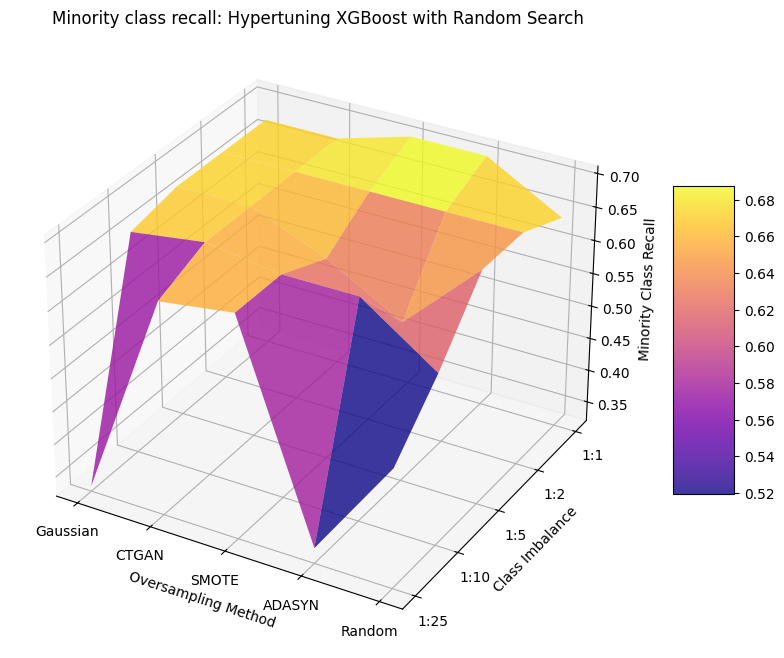

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# 1. Organize the data
data = extract_values([
    results_optuna_gaussian,
    results_optuna_ctgan,
    results_optuna_smote,
    results_optuna_adasyn,
    results_optuna_random
], n=1)

labels = list(data.keys())
sizes = [25, 10, 5, 2, 1]

# 2. Create numerical mappings for the X and Y axes
x_indices = np.arange(len(labels))
y_indices = np.arange(len(sizes))
y_labels = [f'1:{size}' for size in sizes]
X, Y = np.meshgrid(x_indices, y_indices)

# 3. Extract Z values (Recall) into a grid
# We transpose or align based on the meshgrid shape
Z = np.array([data[label] for label in labels]).T

# 4. Plotting
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(X, Y, Z, cmap='plasma', edgecolor='none', alpha=0.8)

# Customize axes
ax.set_xticks(x_indices)
ax.set_xticklabels(labels)
ax.set_yticks(y_indices)
ax.set_yticklabels(y_labels)

ax.set_xlabel('Oversampling Method')
ax.set_ylabel('Class Imbalance')
ax.set_zlabel('Minority Class Recall')
ax.set_title('Minority class recall: Hypertuning XGBoost with Random Search')

# Add a color bar for reference
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

plt.show()

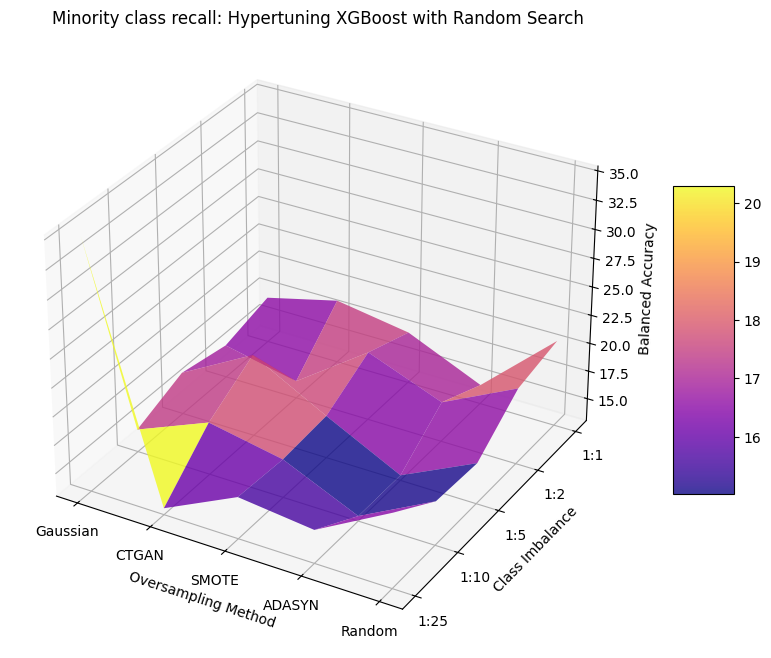

In [30]:
# 1. Organize the data
data = extract_values([
    results_optuna_gaussian,
    results_optuna_ctgan,
    results_optuna_smote,
    results_optuna_adasyn,
    results_optuna_random
], n=2)

labels = list(data.keys())
sizes = [25, 10, 5, 2, 1]

# 2. Create numerical mappings for the X and Y axes
x_indices = np.arange(len(labels))
y_indices = np.arange(len(sizes))
y_labels = [f'1:{size}' for size in sizes]
X, Y = np.meshgrid(x_indices, y_indices)

# 3. Extract Z values (Recall) into a grid
# We transpose or align based on the meshgrid shape
Z = np.array([data[label] for label in labels]).T

# 4. Plotting
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(X, Y, Z, cmap='plasma', edgecolor='none', alpha=0.8)

# Customize axes
ax.set_xticks(x_indices)
ax.set_xticklabels(labels)
ax.set_yticks(y_indices)
ax.set_yticklabels(y_labels)

ax.set_xlabel('Oversampling Method')
ax.set_ylabel('Class Imbalance')
ax.set_zlabel('Balanced Accuracy')
ax.set_title('Minority class recall: Hypertuning XGBoost with Random Search')

# Add a color bar for reference
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

plt.show()

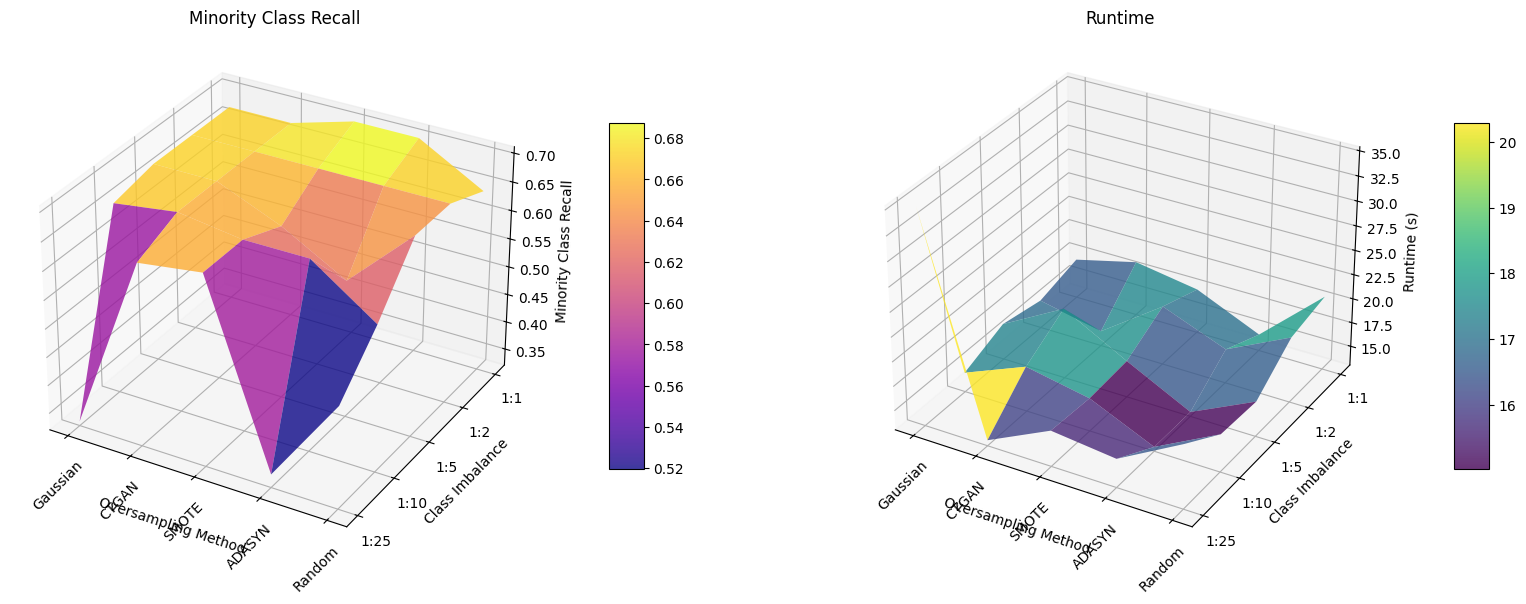

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# 1. Organize the data for both metrics
# Data for Recall (n=1)
data_recall = extract_values([
    results_optuna_gaussian,
    results_optuna_ctgan,
    results_optuna_smote,
    results_optuna_adasyn,
    results_optuna_random
], n=1)

# Data for Balanced Accuracy (n=2)
data_acc = extract_values([
    results_optuna_gaussian,
    results_optuna_ctgan,
    results_optuna_smote,
    results_optuna_adasyn,
    results_optuna_random
], n=2)

labels = list(data_recall.keys())
sizes = [25, 10, 5, 2, 1]

# 2. Create numerical mappings (shared by both)
x_indices = np.arange(len(labels))
y_indices = np.arange(len(sizes))
y_labels = [f'1:{size}' for size in sizes]
X, Y = np.meshgrid(x_indices, y_indices)

# 3. Extract Z values
Z1 = np.array([data_recall[label] for label in labels]).T
Z2 = np.array([data_acc[label] for label in labels]).T

# 4. Plotting in one figure with two subplots
fig = plt.figure(figsize=(20, 9)) # Increased width for two 3D plots

# --- Subplot 1: Minority Class Recall ---
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X, Y, Z1, cmap='plasma', edgecolor='none', alpha=0.8)

ax1.set_xticks(x_indices)
ax1.set_xticklabels(labels, rotation=45)
ax1.set_yticks(y_indices)
ax1.set_yticklabels(y_labels)

ax1.set_xlabel('Oversampling Method')
ax1.set_ylabel('Class Imbalance')
ax1.set_zlabel('Minority Class Recall')
ax1.set_title('Minority Class Recall')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, pad=0.1)

# --- Subplot 2: Balanced Accuracy ---
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X, Y, Z2, cmap='viridis', edgecolor='none', alpha=0.8)

ax2.set_xticks(x_indices)
ax2.set_xticklabels(labels, rotation=45)
ax2.set_yticks(y_indices)
ax2.set_yticklabels(y_labels)

ax2.set_xlabel('Oversampling Method')
ax2.set_ylabel('Class Imbalance')
ax2.set_zlabel('Runtime (s)')
ax2.set_title('Runtime')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, pad=0.1)

plt.tight_layout()
plt.show()

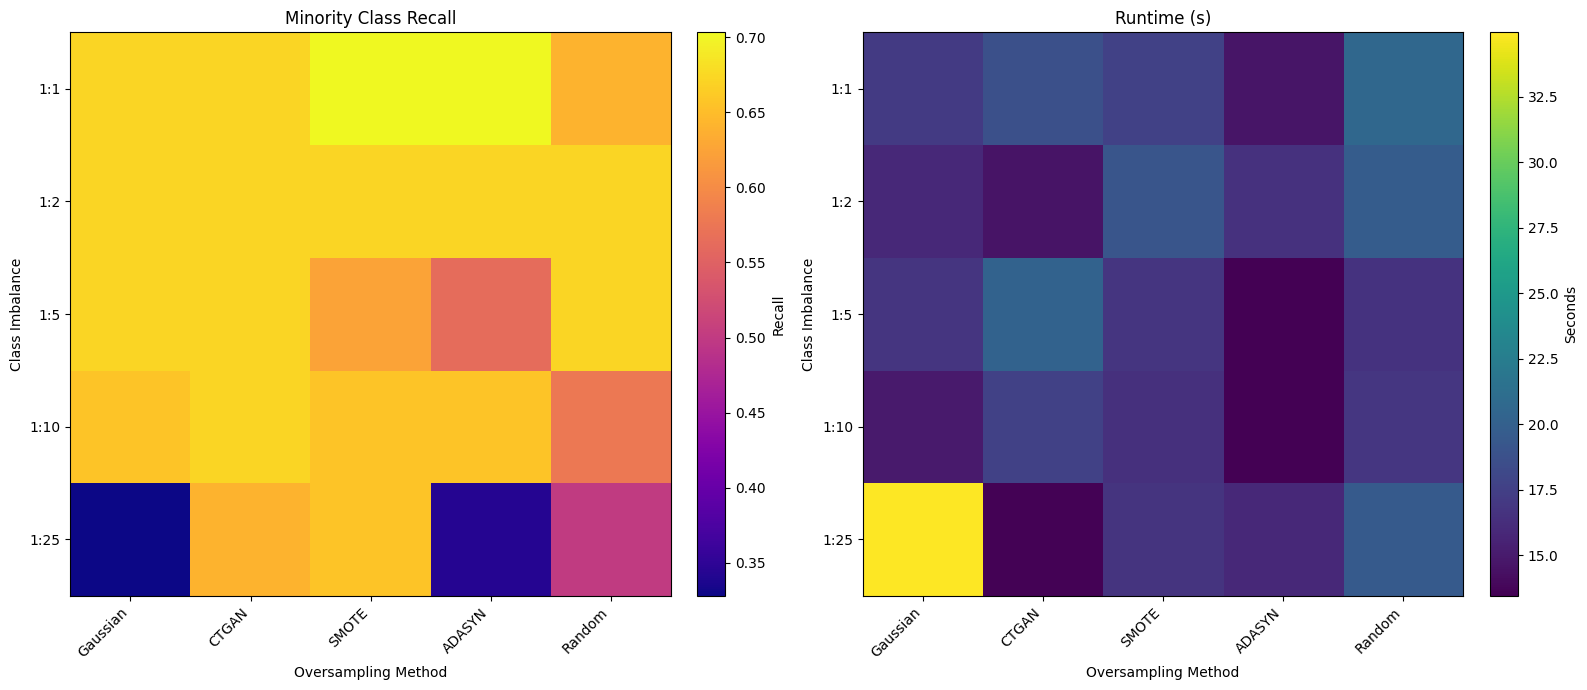

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming data_recall, data_acc, labels, sizes, Z1, Z2 are prepared as in your code

labels = list(data_recall.keys())
sizes = [25, 10, 5, 2, 1]
y_labels = [f'1:{size}' for size in sizes]

# Create figure and axes for two heatmaps side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Heatmap for Minority Class Recall
im1 = ax1.imshow(Z1, aspect='auto', cmap='plasma', origin='lower')

# Set axis ticks and labels
ax1.set_xticks(np.arange(len(labels)))
ax1.set_xticklabels(labels, rotation=45, ha='right')
ax1.set_yticks(np.arange(len(y_labels)))
ax1.set_yticklabels(y_labels)
ax1.set_xlabel('Oversampling Method')
ax1.set_ylabel('Class Imbalance')
ax1.set_title('Minority Class Recall')

# Add colorbar
cbar1 = fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cbar1.set_label('Recall')

# Heatmap for Runtime
im2 = ax2.imshow(Z2, aspect='auto', cmap='viridis', origin='lower')

# Set axis ticks and labels
ax2.set_xticks(np.arange(len(labels)))
ax2.set_xticklabels(labels, rotation=45, ha='right')
ax2.set_yticks(np.arange(len(y_labels)))
ax2.set_yticklabels(y_labels)
ax2.set_xlabel('Oversampling Method')
ax2.set_ylabel('Class Imbalance')
ax2.set_title('Runtime (s)')

# Add colorbar
cbar2 = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cbar2.set_label('Seconds')

plt.tight_layout()
plt.show()

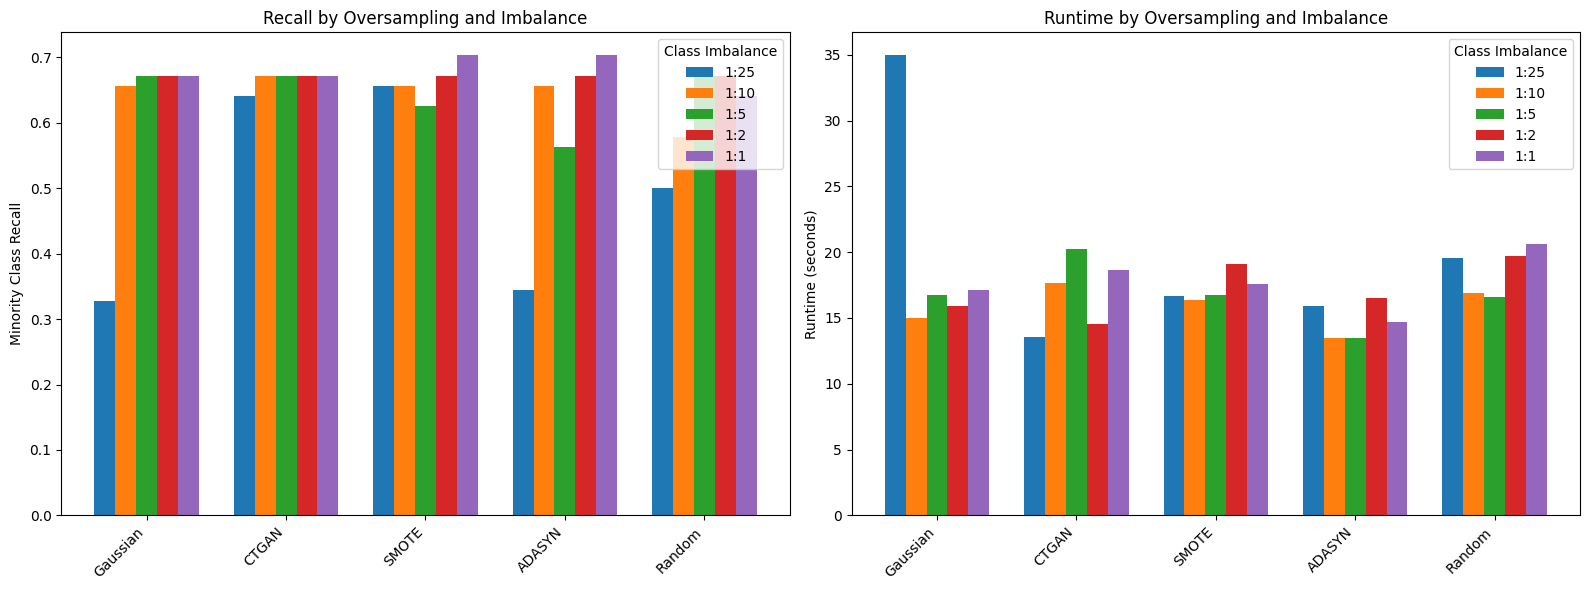

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

x = np.arange(len(labels))  # oversampling methods
width = 0.15

for i, size in enumerate(sizes):
    recall_vals = Z1[i]
    runtime_vals = Z2[i]
    ax1.bar(x + i*width, recall_vals, width, label=f'1:{size}')
    ax2.bar(x + i*width, runtime_vals, width, label=f'1:{size}')

ax1.set_xticks(x + width * (len(sizes)-1) / 2)
ax1.set_xticklabels(labels, rotation=45, ha='right')
ax1.set_ylabel('Minority Class Recall')
ax1.set_title('Recall by Oversampling and Imbalance')
ax1.legend(title='Class Imbalance')

ax2.set_xticks(x + width * (len(sizes)-1) / 2)
ax2.set_xticklabels(labels, rotation=45, ha='right')
ax2.set_ylabel('Runtime (seconds)')
ax2.set_title('Runtime by Oversampling and Imbalance')
ax2.legend(title='Class Imbalance')

plt.tight_layout()
plt.show()